In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import os
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 64
BATCH_SIZE = 64
LATENT_DIM = 100
NUM_EPOCHS = 30
LR = 2e-4
workers = 2
ADAM_BETA_1 = 0.5


NUM_CLASSES = 2  # Long Hair / Not Long Hair
IMG_CHANNELS = 3
IMG_SHAPE = (IMG_CHANNELS, IMAGE_SIZE, IMAGE_SIZE)

In [2]:
import os
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image

class LongHairCelebADataset(Dataset):
    def __init__(self, img_dir, attr_file, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        
        # Load CSV with proper delimiter
        self.attrs = pd.read_csv(attr_file)  # <-- Updated from read_table
        self.image_names = self.attrs['image_id'].tolist()

        # Label: 1 for long hair (not male and not bald), 0 otherwise
        self.labels = []
        for _, row in self.attrs.iterrows():
            is_male = row['Male'] == 1
            is_bald = row['Bald'] == 1
            label = 1 if not is_male and not is_bald else 0
            self.labels.append(label)

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]
        return image, label


In [3]:
DATA_DIR = '/home/cse/Documents/NP/datasets/CelebA'
img_dir_path = os.path.join(DATA_DIR, 'img_align_celeba/img_align_celeba')
attr_file_path = os.path.join(DATA_DIR, 'list_attr_celeba.csv')

IMAGE_SIZE = 64
BATCH_SIZE = 16
workers = 2

transformations = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_dataset = LongHairCelebADataset(img_dir=img_dir_path, attr_file=attr_file_path, transform=transformations)
subset_indices = list(range(5000))
celeba_dataset = torch.utils.data.Subset(full_dataset, subset_indices)
dataloader = torch.utils.data.DataLoader(celeba_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=workers)

labels_np = np.array([full_dataset.labels[i] for i in subset_indices])
print(f"Subset loaded: {len(celeba_dataset)} images")
print(f"Long hair: {np.sum(labels_np == 1)}")
print(f"Not long hair: {np.sum(labels_np == 0)}")

Subset loaded: 5000 images
Long hair: 2917
Not long hair: 2083


In [4]:
class Generator(nn.Module):
    def __init__(self, latent_dim, num_classes, img_shape):
        super(Generator, self).__init__()
        self.label_emb = nn.Embedding(num_classes, latent_dim)
        self.img_shape = img_shape
        input_dim = latent_dim * 2

        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, int(np.prod(img_shape))),
            nn.Tanh()
        )

    def forward(self, z, labels):
        label_embed = self.label_emb(labels.long())
        x = torch.cat((z, label_embed), dim=1)
        img = self.model(x)
        img = img.view(img.size(0), *self.img_shape)
        return img


In [5]:
class Discriminator(nn.Module):
    def __init__(self, num_classes, img_shape):
        super(Discriminator, self).__init__()
        self.img_shape = img_shape
        self.label_emb = nn.Embedding(num_classes, int(np.prod(img_shape)))

        self.model = nn.Sequential(
            nn.Linear(int(np.prod(img_shape)) * 2, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        img_flat = img.view(img.size(0), -1)
        label_embed = self.label_emb(labels.long())
        d_in = torch.cat((img_flat, label_embed), dim=1)
        validity = self.model(d_in)
        return validity

In [6]:
G = Generator(latent_dim=LATENT_DIM, num_classes=NUM_CLASSES, img_shape=IMG_SHAPE).to(device)
D = Discriminator(num_classes=NUM_CLASSES, img_shape=IMG_SHAPE).to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))


In [7]:
def train_cgan(dataloader, epochs):
    G_losses, D_losses = [], []

    for epoch in range(epochs):
        for imgs, labels in dataloader:
            batch_size = imgs.size(0)
            valid = torch.ones(batch_size, 1).to(device)
            fake = torch.zeros(batch_size, 1).to(device)
            real_imgs = imgs.to(device)
            labels = labels.long().to(device)

            # -----------------
            #  Train Generator
            # -----------------
            optimizer_G.zero_grad()
            z = torch.randn(batch_size, LATENT_DIM).to(device)
            gen_imgs = G(z, labels)
            g_loss = criterion(D(gen_imgs, labels), valid)
            g_loss.backward()
            optimizer_G.step()

            # ---------------------
            #  Train Discriminator
            # ---------------------
            optimizer_D.zero_grad()
            real_loss = criterion(D(real_imgs, labels), valid)
            fake_loss = criterion(D(gen_imgs.detach(), labels), fake)
            d_loss = (real_loss + fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()

        G_losses.append(g_loss.item())
        D_losses.append(d_loss.item())
        print(f"Epoch [{epoch+1}/{epochs}]  Loss_D: {d_loss.item():.4f}  Loss_G: {g_loss.item():.4f}")

    return G_losses, D_losses


if __name__ == '__main__':
    G_losses, D_losses = train_cgan(dataloader, NUM_EPOCHS)
    torch.save(G.state_dict(), 'cgan_generator.pth')
    torch.save(D.state_dict(), 'cgan_discriminator.pth')


Epoch [1/30]  Loss_D: 0.5136  Loss_G: 1.1922


Epoch [2/30]  Loss_D: 0.5931  Loss_G: 1.0925
Epoch [3/30]  Loss_D: 0.4640  Loss_G: 1.2608
Epoch [4/30]  Loss_D: 0.4612  Loss_G: 1.1321
Epoch [5/30]  Loss_D: 0.5761  Loss_G: 1.6251
Epoch [6/30]  Loss_D: 0.5849  Loss_G: 0.7553
Epoch [7/30]  Loss_D: 0.4276  Loss_G: 1.0648
Epoch [8/30]  Loss_D: 0.4348  Loss_G: 1.5262
Epoch [9/30]  Loss_D: 0.4087  Loss_G: 1.2268
Epoch [10/30]  Loss_D: 0.4363  Loss_G: 1.2321
Epoch [11/30]  Loss_D: 0.5669  Loss_G: 1.0597
Epoch [12/30]  Loss_D: 0.5424  Loss_G: 1.2954
Epoch [13/30]  Loss_D: 0.6089  Loss_G: 0.8343
Epoch [14/30]  Loss_D: 0.7184  Loss_G: 0.8651
Epoch [15/30]  Loss_D: 0.8142  Loss_G: 0.4271
Epoch [16/30]  Loss_D: 0.7942  Loss_G: 1.0560
Epoch [17/30]  Loss_D: 0.6796  Loss_G: 0.7011
Epoch [18/30]  Loss_D: 0.6274  Loss_G: 0.5512
Epoch [19/30]  Loss_D: 0.6528  Loss_G: 0.7523
Epoch [20/30]  Loss_D: 0.6455  Loss_G: 0.8077
Epoch [21/30]  Loss_D: 0.6934  Loss_G: 1.1953
Epoch [22/30]  Loss_D: 0.5710  Loss_G: 0.8424
Epoch [23/30]  Loss_D: 0.5636  Loss_G: 1.3

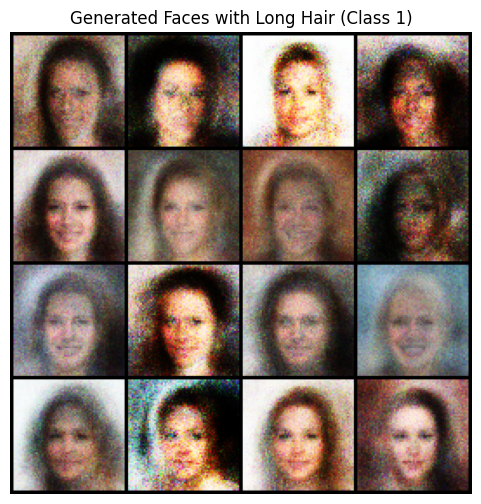

In [8]:
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

# Set model to evaluation mode
G.eval()

# Generate noise and long-hair labels
z = torch.randn(16, LATENT_DIM).to(device)  # Random noise
labels = torch.ones(16, dtype=torch.long).to(device)  # Class label = 1 (long hair)

# Generate fake images
with torch.no_grad():
    gen_imgs = G(z, labels).cpu()

# Rescale images from [-1, 1] to [0, 1]
gen_imgs = (gen_imgs + 1) / 2

# Display image grid
grid = make_grid(gen_imgs, nrow=4)
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.title("Generated Faces with Long Hair (Class 1)")
plt.show()


In [9]:
from torchvision.utils import save_image
save_image(gen_imgs, "generated_longhair_faces.png", nrow=4, normalize=True)


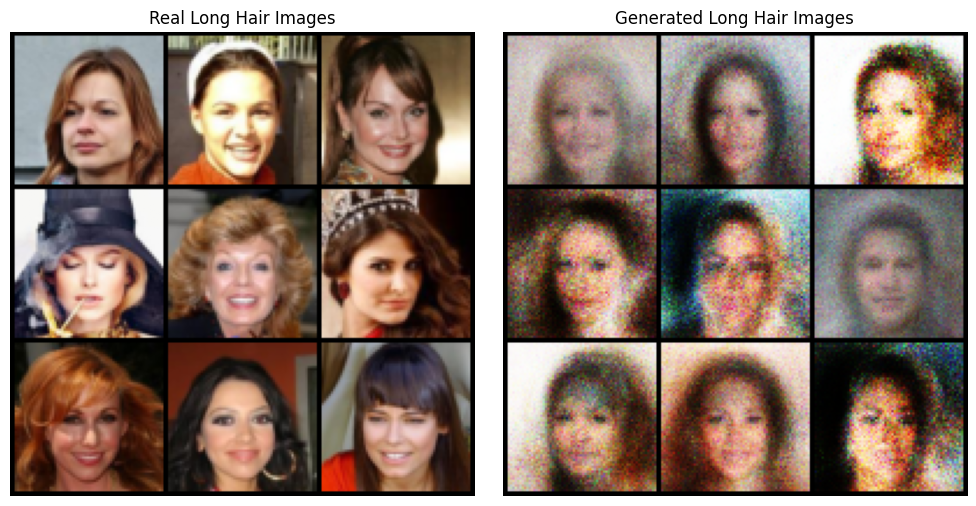

In [10]:
import matplotlib.pyplot as plt
import torch
from torchvision.utils import make_grid

# Collect 9 real images with long hair (label == 1)
real_samples = []
real_labels = []

for real_imgs, labels in dataloader:
    idx = (labels == 1).nonzero(as_tuple=True)[0]
    if len(idx) > 0:
        real_samples.append(real_imgs[idx])
        real_labels.append(labels[idx])
    if sum(x.size(0) for x in real_samples) >= 9:
        break

real_imgs = torch.cat(real_samples, dim=0)[:9].to(device)
labels = torch.cat(real_labels, dim=0)[:9].to(device)

# Generate 9 fake images with long hair
z = torch.randn(9, LATENT_DIM).to(device)
long_hair_labels = torch.ones(9, dtype=torch.long).to(device)

G.eval()
with torch.no_grad():
    fake_imgs = G(z, long_hair_labels).cpu()

# Move real images to CPU and denormalize
real_imgs = real_imgs.cpu()
real_imgs = (real_imgs + 1) / 2
fake_imgs = (fake_imgs + 1) / 2

# Create grids
real_grid = make_grid(real_imgs, nrow=3, normalize=False)
fake_grid = make_grid(fake_imgs, nrow=3, normalize=False)

# Plot side-by-side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(real_grid.permute(1, 2, 0))
plt.axis('off')
plt.title('Real Long Hair Images')

plt.subplot(1, 2, 2)
plt.imshow(fake_grid.permute(1, 2, 0))
plt.axis('off')
plt.title('Generated Long Hair Images')

plt.tight_layout()
plt.show()


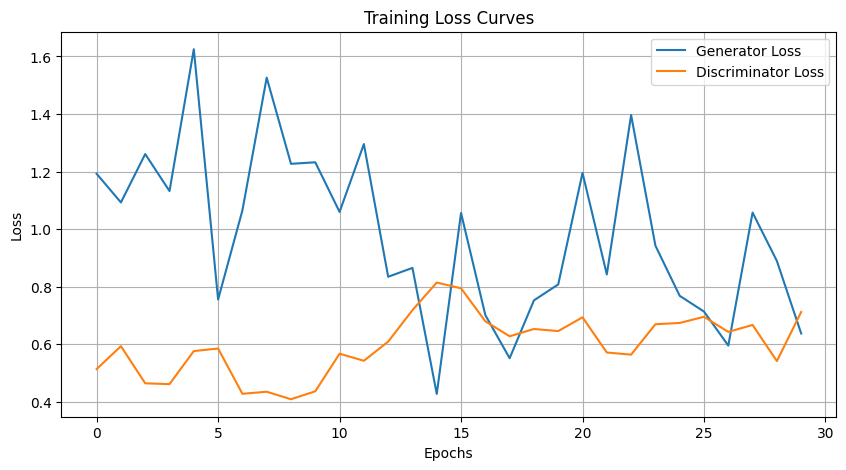

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.grid(True)
plt.show()
